# Task 5: Personal Loan Acceptance Prediction

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Predict which customers are likely to accept a personal loan offer based on their demographic and financial profile.

### Dataset:
Bank Marketing Dataset (UCI Machine Learning Repository / Kaggle)

### Models Used:
- Logistic Regression
- Decision Tree Classifier

### Tools Used:
Python 3.10, pandas, matplotlib, seaborn, scikit-learn

In [5]:
# ============================
# Step 1 & 2: Import Libraries and Load Dataset
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

print("All libraries imported successfully!")

# Load Dataset
df = pd.read_csv('bank.csv')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

All libraries imported successfully!
Dataset loaded successfully!
Total Rows: 11162
Total Columns: 17


In [6]:
# ============================
# Step 3: Display First 5 Rows
# ============================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [7]:
# ============================
# Step 4: Dataset Structure
# ============================

# Shape
print("Dataset Shape:", df.shape)
print()

# Column Names and Data Types
print("Column Names and Data Types:")
print("-" * 50)
for col in df.columns:
    print(f"  {col:20s} -> {df[col].dtype}")
print()

# Statistical Summary
print("Statistical Summary:")
df.describe()

Dataset Shape: (11162, 17)

Column Names and Data Types:
--------------------------------------------------
  age                  -> int64
  job                  -> object
  marital              -> object
  education            -> object
  default              -> object
  balance              -> int64
  housing              -> object
  loan                 -> object
  contact              -> object
  day                  -> int64
  month                -> object
  duration             -> int64
  campaign             -> int64
  pdays                -> int64
  previous             -> int64
  poutcome             -> object
  deposit              -> object

Statistical Summary:


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
# ============================
# Step 5: Detailed Dataset Info
# ============================

print("Dataset Info:")
print("=" * 50)
df.info()
print()

# Unique values
print("\nUnique Values in Each Column:")
print("=" * 50)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(f"   Values: {df[col].unique()}")
    print()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


Unique Values in Each Column:
age: 76 unique values

job: 12 unique values
   Value

In [9]:
# ============================
# Step 6: Check for Missing Values
# ============================

print("Missing Values:")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total Missing Values: 0


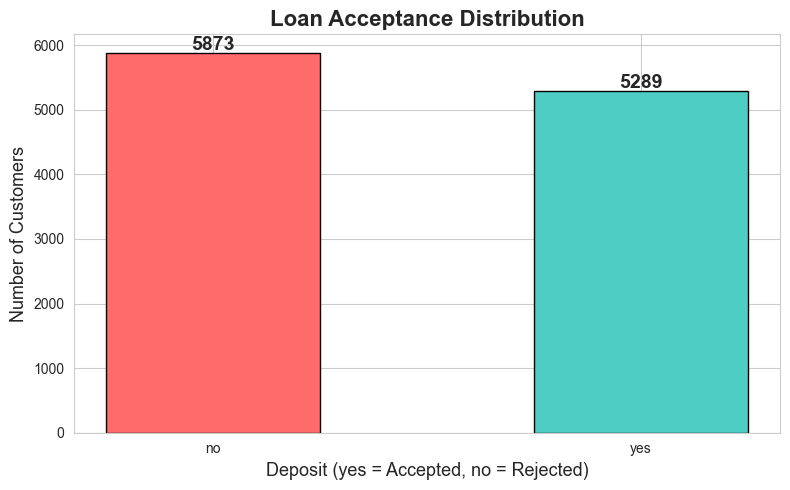

Accepted (yes): 5289 (47.4%)
Rejected (no): 5873 (52.6%)


In [10]:
# ============================
# Step 7: Target Variable Distribution (deposit)
# ============================
# 'deposit' column tells if customer accepted the offer (yes/no)

plt.figure(figsize=(8, 5))

counts = df['deposit'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']

bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=14, fontweight='bold')

plt.title('Loan Acceptance Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Deposit (yes = Accepted, no = Rejected)', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Accepted (yes): {counts['yes']} ({counts['yes']/len(df)*100:.1f}%)")
print(f"Rejected (no): {counts['no']} ({counts['no']/len(df)*100:.1f}%)")

## Exploratory Data Analysis (EDA)

Analyzing key features to understand customer patterns:
1. Age Distribution
2. Job vs Loan Acceptance
3. Marital Status vs Loan Acceptance
4. Education vs Loan Acceptance
5. Balance Analysis

C:\Users\home computers\AppData\Local\Temp\ipykernel_1056\3619017680.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='age', ax=axes[1],


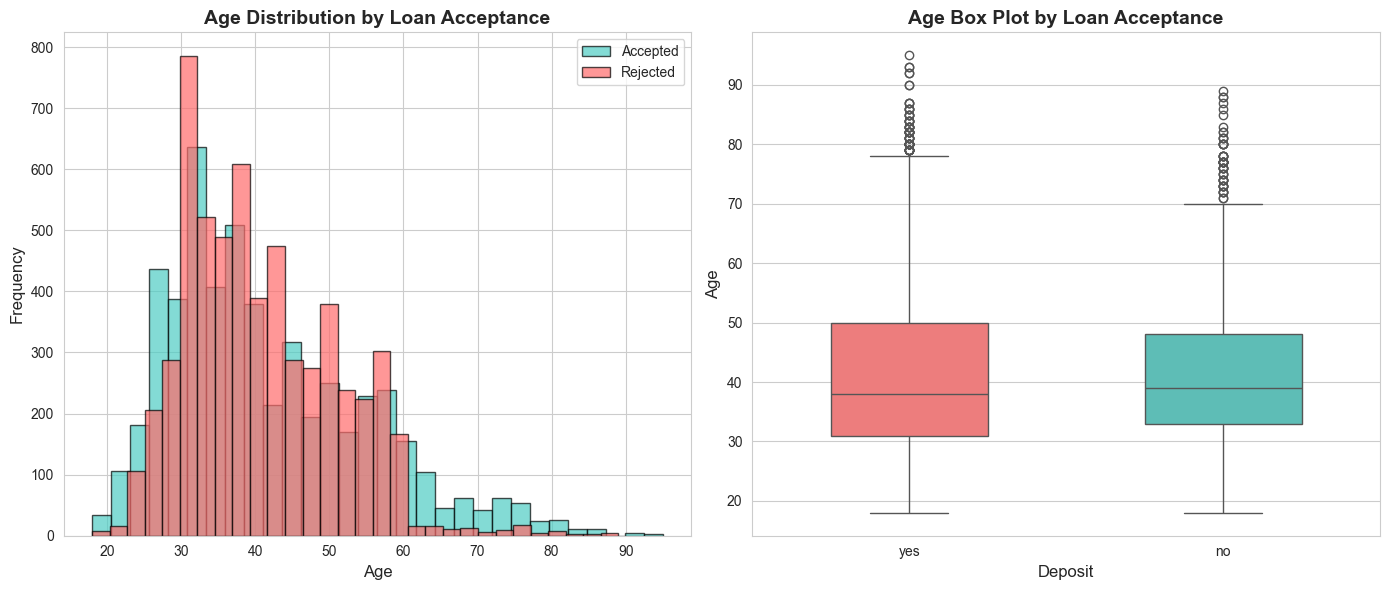

Average age - Accepted: 41.7
Average age - Rejected: 40.8


In [11]:
# ============================
# Step 8: Age Distribution by Loan Acceptance
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
df[df['deposit'] == 'yes']['age'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#4ECDC4', edgecolor='black', label='Accepted')
df[df['deposit'] == 'no']['age'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#FF6B6B', edgecolor='black', label='Rejected')
axes[0].set_title('Age Distribution by Loan Acceptance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box Plot
sns.boxplot(data=df, x='deposit', y='age', ax=axes[1],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[1].set_title('Age Box Plot by Loan Acceptance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Deposit', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Average age - Accepted: {df[df['deposit']=='yes']['age'].mean():.1f}")
print(f"Average age - Rejected: {df[df['deposit']=='no']['age'].mean():.1f}")

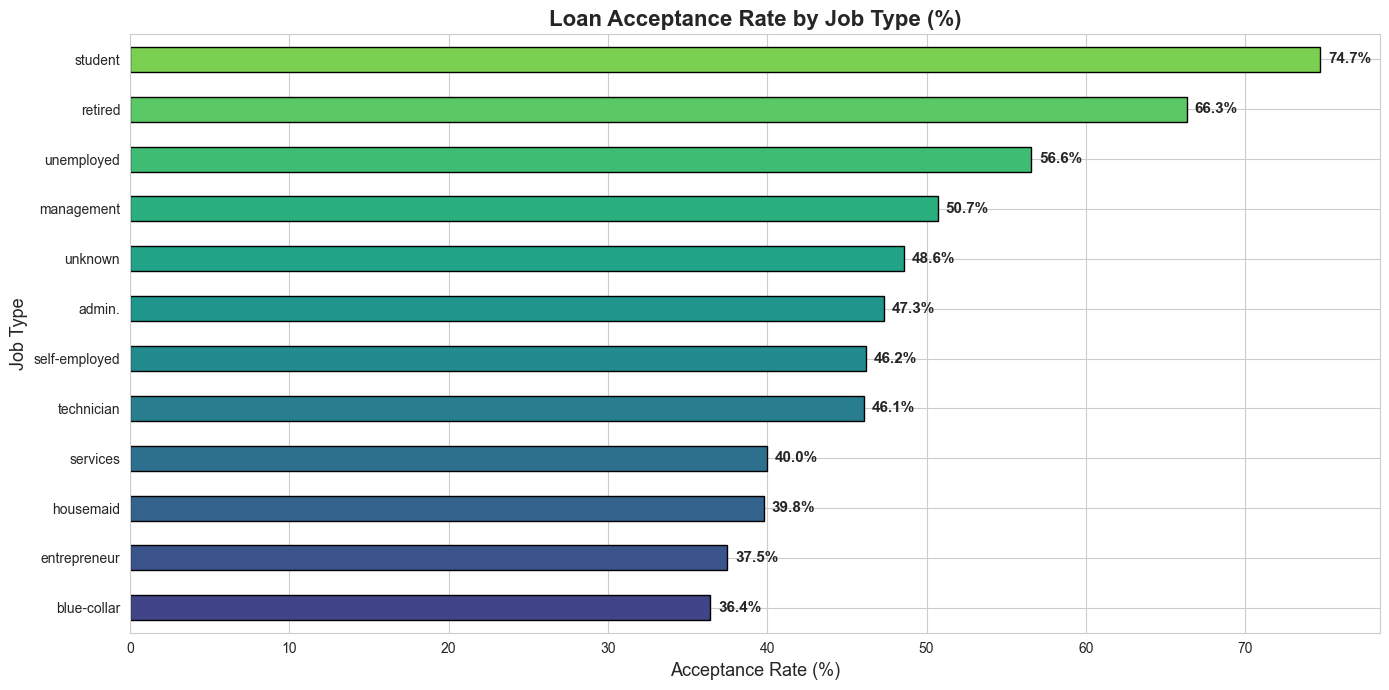

Top 3 Jobs with Highest Acceptance Rate:
  1. unemployed: 56.6%
  2. retired: 66.3%
  3. student: 74.7%


In [12]:
# ============================
# Step 9: Job vs Loan Acceptance
# ============================

plt.figure(figsize=(14, 7))

# Acceptance rate by job
acceptance_by_job = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=True)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(acceptance_by_job)))
acceptance_by_job.plot(kind='barh', color=colors, edgecolor='black')

plt.title('Loan Acceptance Rate by Job Type (%)', fontsize=16, fontweight='bold')
plt.xlabel('Acceptance Rate (%)', fontsize=13)
plt.ylabel('Job Type', fontsize=13)

# Add percentage labels
for i, v in enumerate(acceptance_by_job.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Top 3 Jobs with Highest Acceptance Rate:")
for i, (job, rate) in enumerate(acceptance_by_job.tail(3).items(), 1):
    print(f"  {i}. {job}: {rate:.1f}%")

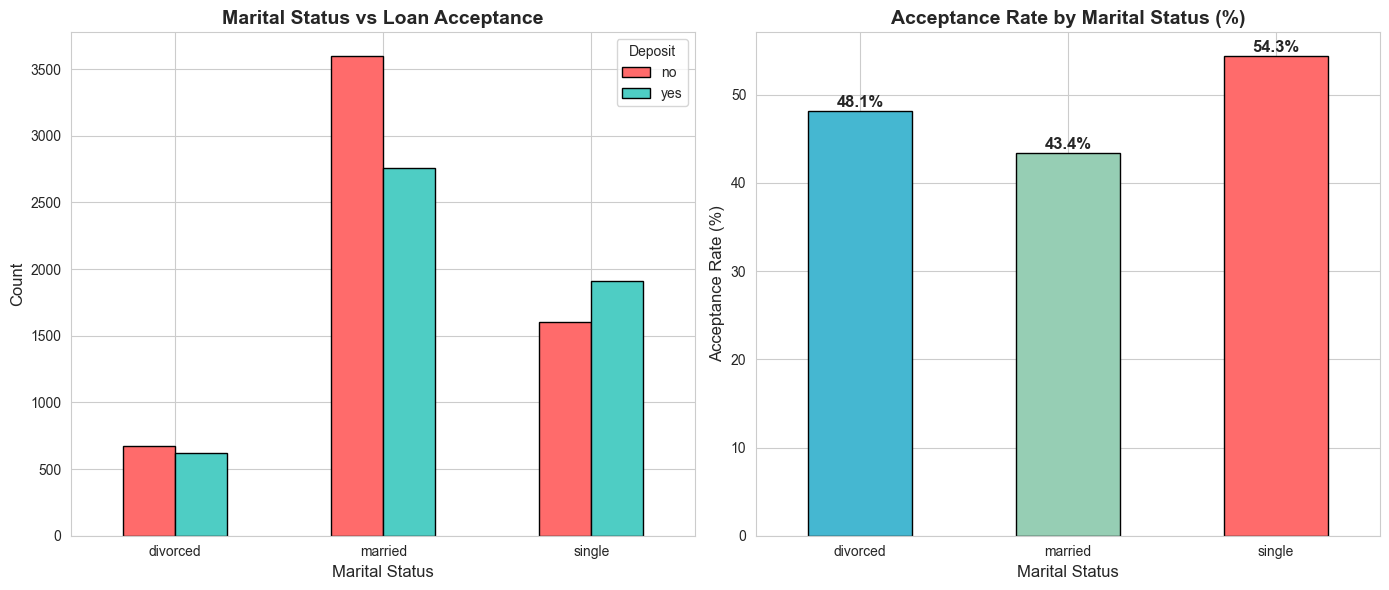

In [13]:
# ============================
# Step 10: Marital Status vs Loan Acceptance
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count Plot
pd.crosstab(df['marital'], df['deposit']).plot(kind='bar', ax=axes[0],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Marital Status vs Loan Acceptance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Marital Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Deposit')

# Acceptance Rate
acceptance_by_marital = df.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
acceptance_by_marital.plot(kind='bar', ax=axes[1], color=['#45B7D1', '#96CEB4', '#FF6B6B'],
                           edgecolor='black')
axes[1].set_title('Acceptance Rate by Marital Status (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marital Status', fontsize=12)
axes[1].set_ylabel('Acceptance Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(acceptance_by_marital.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

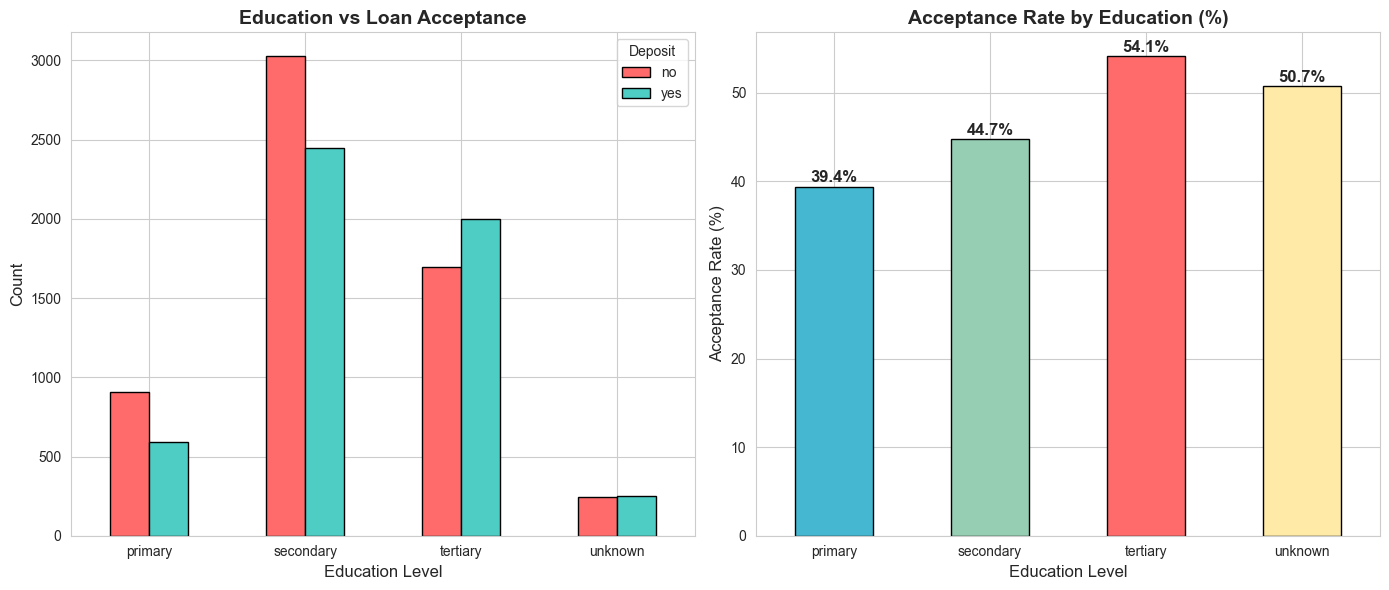

In [14]:
# ============================
# Step 11: Education vs Loan Acceptance
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count Plot
pd.crosstab(df['education'], df['deposit']).plot(kind='bar', ax=axes[0],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Education vs Loan Acceptance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Education Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Deposit')

# Acceptance Rate
acceptance_by_edu = df.groupby('education')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
acceptance_by_edu.plot(kind='bar', ax=axes[1], color=['#45B7D1', '#96CEB4', '#FF6B6B', '#FFEAA7'],
                       edgecolor='black')
axes[1].set_title('Acceptance Rate by Education (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=12)
axes[1].set_ylabel('Acceptance Rate (%)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(acceptance_by_edu.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\home computers\AppData\Local\Temp\ipykernel_1056\3460447779.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='balance', ax=axes[1],


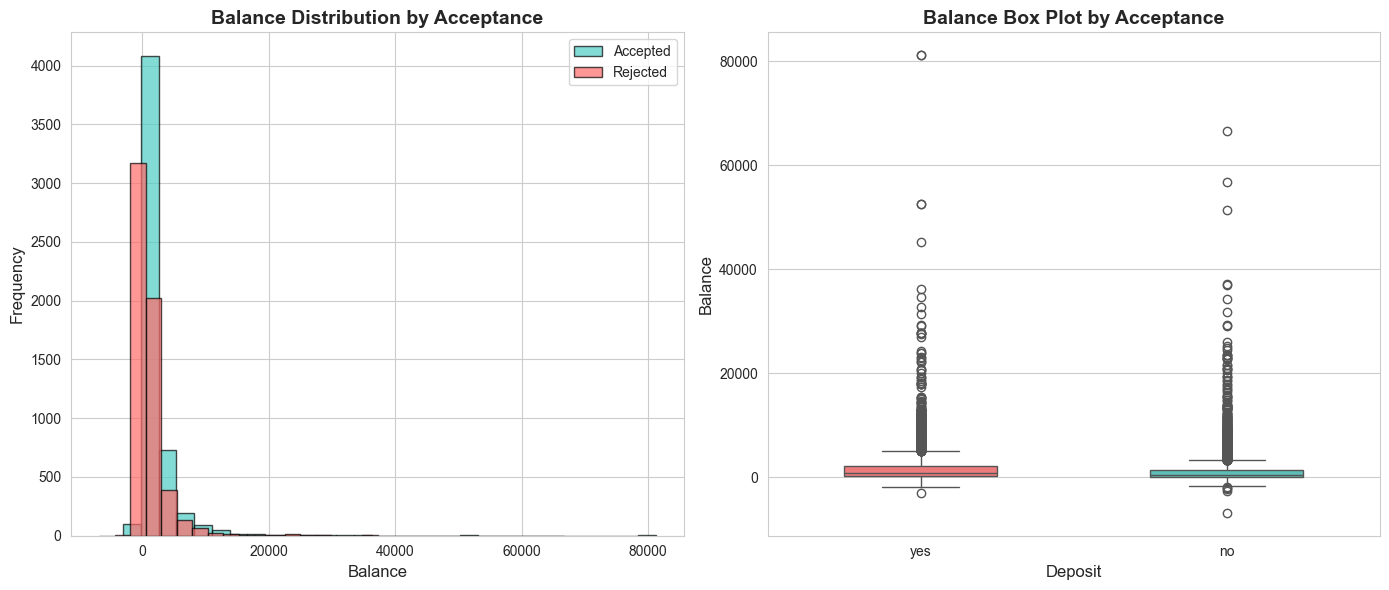

Average balance - Accepted: 1804
Average balance - Rejected: 1280

Observation: Customers who accepted have higher average balance!


In [15]:
# ============================
# Step 12: Balance Analysis
# ============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Balance Distribution
df[df['deposit'] == 'yes']['balance'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#4ECDC4', edgecolor='black', label='Accepted')
df[df['deposit'] == 'no']['balance'].hist(bins=30, ax=axes[0], alpha=0.7,
    color='#FF6B6B', edgecolor='black', label='Rejected')
axes[0].set_title('Balance Distribution by Acceptance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Balance', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Balance Box Plot
sns.boxplot(data=df, x='deposit', y='balance', ax=axes[1],
            palette=['#FF6B6B', '#4ECDC4'], width=0.5)
axes[1].set_title('Balance Box Plot by Acceptance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Deposit', fontsize=12)
axes[1].set_ylabel('Balance', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Average balance - Accepted: {df[df['deposit']=='yes']['balance'].mean():.0f}")
print(f"Average balance - Rejected: {df[df['deposit']=='no']['balance'].mean():.0f}")
print("\nObservation: Customers who accepted have higher average balance!")

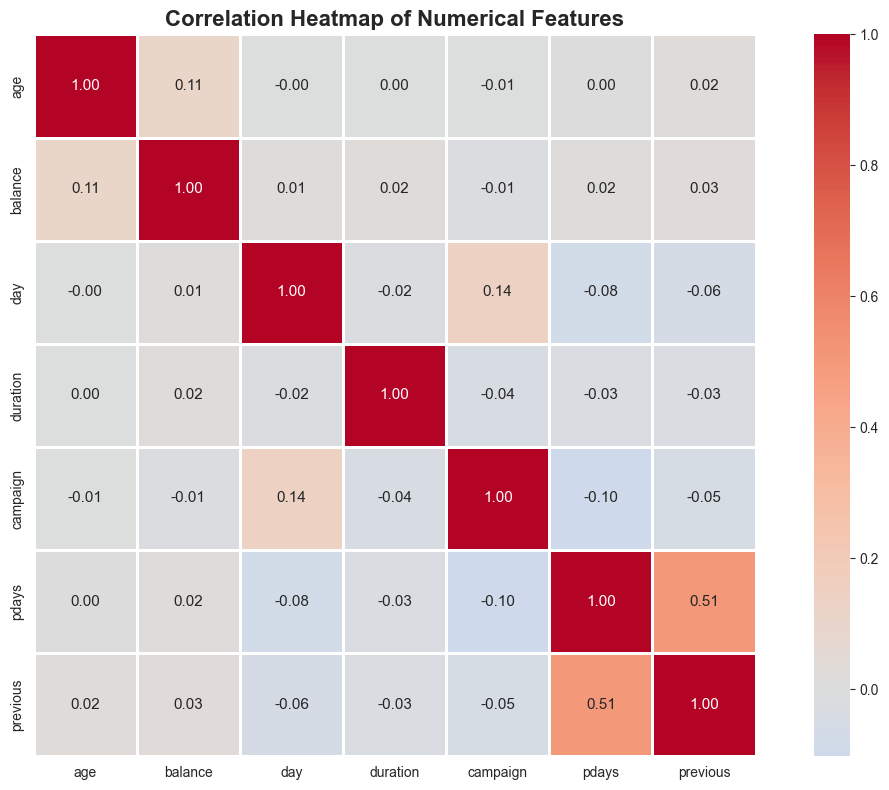

In [16]:
# ============================
# Step 13: Correlation Heatmap
# ============================

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    fmt='.2f',
    annot_kws={'fontsize': 11}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Building

### Steps:
1. Encode all categorical variables using Label Encoding
2. Define features (X) and target (y)
3. Split data into training (80%) and testing (20%)
4. Train Logistic Regression model
5. Train Decision Tree model
6. Compare models and extract business insights

In [17]:
# ============================
# Step 14: Encode Categorical Variables
# ============================

df_model = df.copy()

le = LabelEncoder()

categorical_columns = df_model.select_dtypes(include='object').columns
print("Encoding Categorical Columns:")
print("-" * 40)

for col in categorical_columns:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  {col}: Encoded successfully")

print()
print("Encoded Dataset - First 5 Rows:")
df_model.head()

Encoding Categorical Columns:
----------------------------------------
  job: Encoded successfully
  marital: Encoded successfully
  education: Encoded successfully
  default: Encoded successfully
  housing: Encoded successfully
  loan: Encoded successfully
  contact: Encoded successfully
  month: Encoded successfully
  poutcome: Encoded successfully
  deposit: Encoded successfully

Encoded Dataset - First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [18]:
# ============================
# Step 15: Split Data into Training and Testing Sets
# ============================

# Features (X) - all columns except 'deposit'
X = df_model.drop('deposit', axis=1)

# Target (y) - 'deposit' column
y = df_model['deposit']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Complete!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"\nTraining: {X_train.shape[0]/len(df_model)*100:.0f}%")
print(f"Testing: {X_test.shape[0]/len(df_model)*100:.0f}%")

Data Split Complete!
Training samples: 8929
Testing samples: 2233

Training: 80%
Testing: 20%


In [19]:
# ============================
# Step 16: Train Logistic Regression Model
# ============================

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"\nAccuracy: {lr_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=['Rejected', 'Accepted']))

LOGISTIC REGRESSION RESULTS

Accuracy: 77.92%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.78      0.80      0.79      1166
    Accepted       0.77      0.76      0.77      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



c:\Users\home computers\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


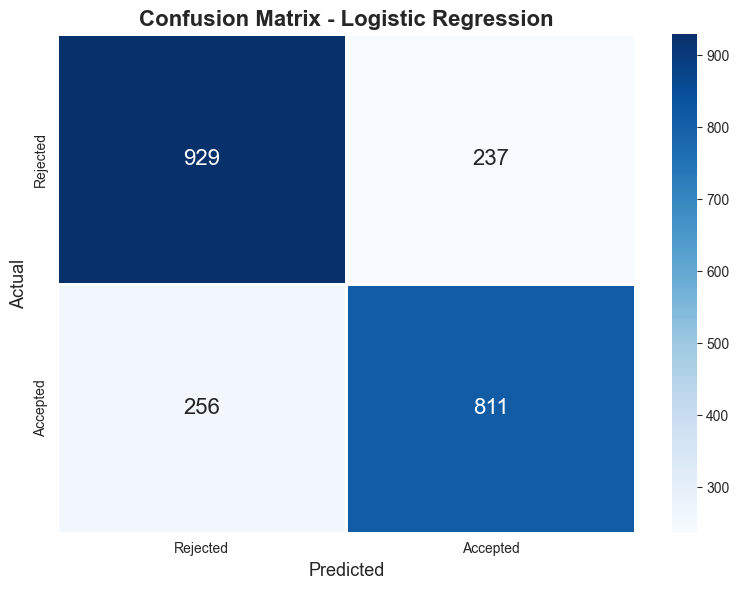

In [20]:
# ============================
# Step 17: Confusion Matrix - Logistic Regression
# ============================

plt.figure(figsize=(8, 6))

cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# ============================
# Step 18: Train Decision Tree Classifier
# ============================

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"\nAccuracy: {dt_accuracy * 100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, dt_predictions, target_names=['Rejected', 'Accepted']))

DECISION TREE RESULTS

Accuracy: 80.52%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.86      0.74      0.80      1166
    Accepted       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



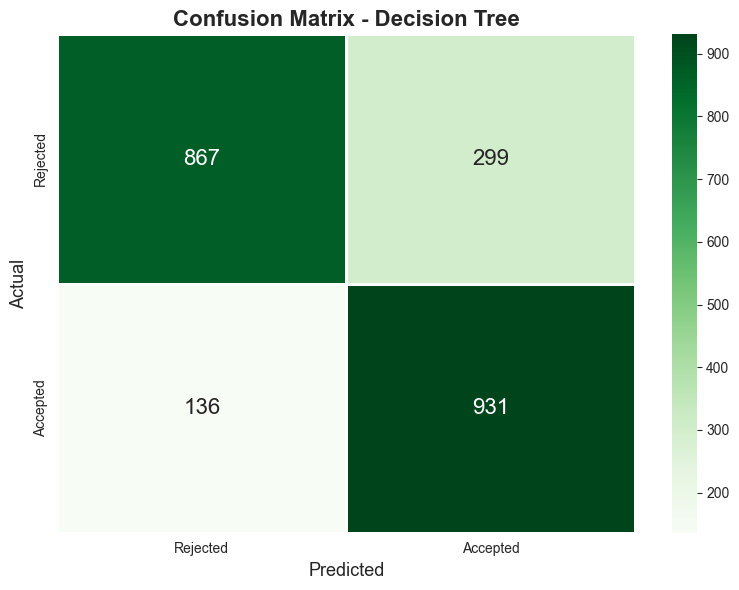

In [22]:
# ============================
# Step 19: Confusion Matrix - Decision Tree
# ============================

plt.figure(figsize=(8, 6))

cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Rejected', 'Accepted'],
            yticklabels=['Rejected', 'Accepted'],
            annot_kws={'fontsize': 16}, linewidths=2)

plt.title('Confusion Matrix - Decision Tree', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

MODEL COMPARISON

Logistic Regression Accuracy: 77.92%
Decision Tree Accuracy:       80.52%


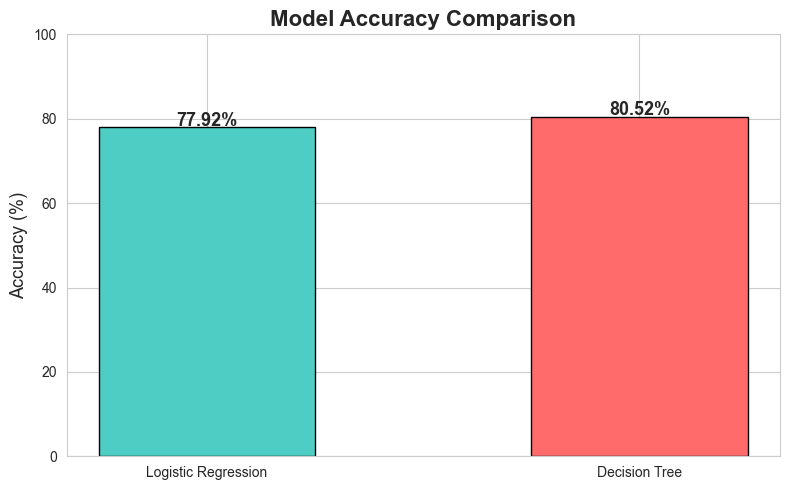


Decision Tree performs better!


In [23]:
# ============================
# Step 20: Model Comparison
# ============================

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"\nLogistic Regression Accuracy: {lr_accuracy * 100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_accuracy * 100:.2f}%")

# Visual Comparison
plt.figure(figsize=(8, 5))

models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy * 100, dt_accuracy * 100]
colors = ['#4ECDC4', '#FF6B6B']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontsize=13, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

if lr_accuracy > dt_accuracy:
    print("\nLogistic Regression performs better!")
elif dt_accuracy > lr_accuracy:
    print("\nDecision Tree performs better!")
else:
    print("\nBoth models have equal accuracy!")

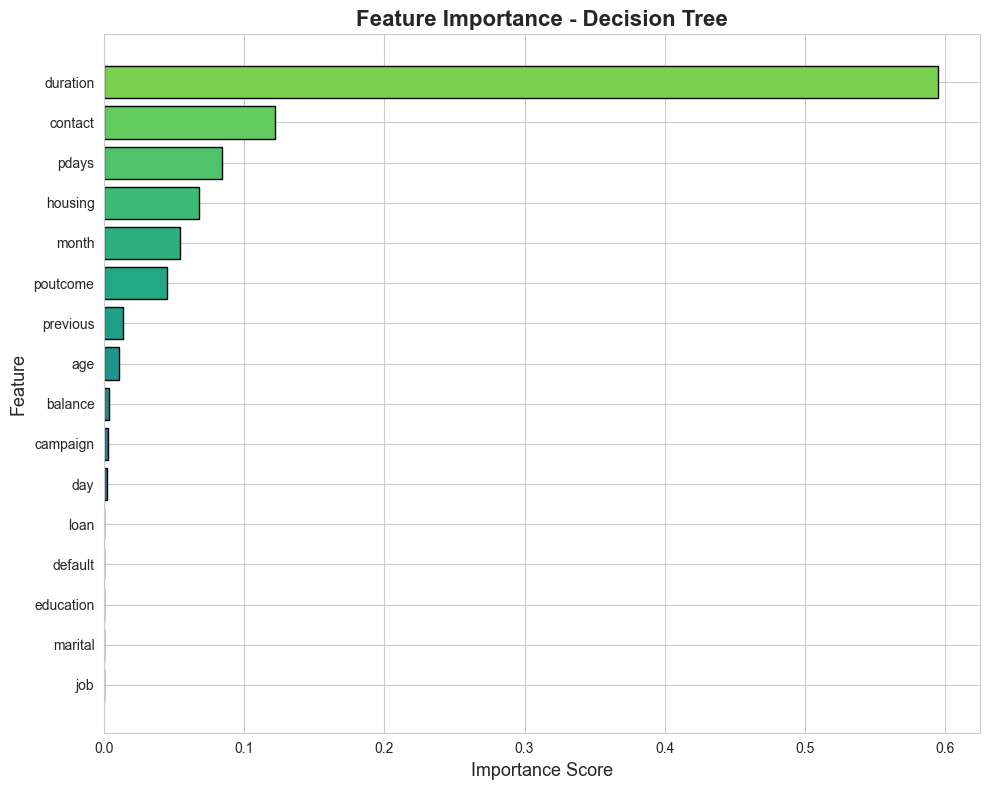


Top 5 Most Important Features:
--------------------------------------------------
  1. month (Importance: 0.0540)
  2. housing (Importance: 0.0675)
  3. pdays (Importance: 0.0843)
  4. contact (Importance: 0.1217)
  5. duration (Importance: 0.5952)


In [24]:
# ============================
# Step 21: Feature Importance (Decision Tree)
# ============================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance)))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color=colors, edgecolor='black')
plt.title('Feature Importance - Decision Tree', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print("-" * 50)
top_5 = feature_importance.tail(5)
for rank, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"  {rank}. {row['Feature']} (Importance: {row['Importance']:.4f})")

BUSINESS INSIGHTS: Customer Groups Likely to Accept Loan

1. Acceptance Rate by Age Group:
   18-30: 57.1%
   31-40: 43.3%
   41-50: 40.8%
   51-60: 43.6%
   60+: 82.2%

2. Top 3 Jobs with Highest Acceptance:
   1. student: 74.7%
   2. retired: 66.3%
   3. unemployed: 56.6%

3. Acceptance Rate by Marital Status:
   divorced: 48.1%
   married: 43.4%
   single: 54.3%


C:\Users\home computers\AppData\Local\Temp\ipykernel_1056\3337546739.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_by_age = df.groupby('age_group')['deposit'].apply(


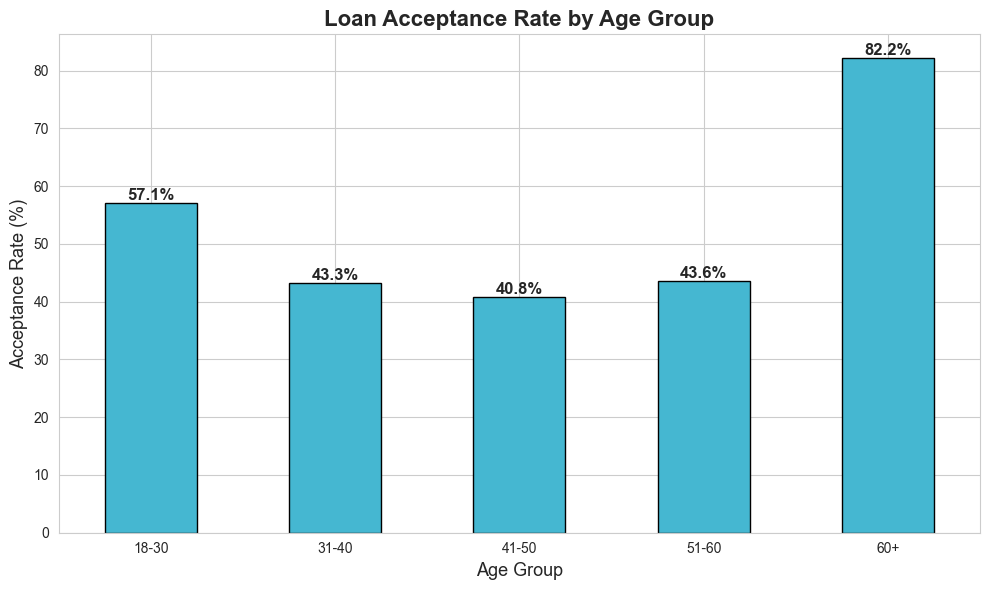

In [25]:
# ============================
# Step 22: Business Insights - Which Customer Groups Accept More
# ============================

print("=" * 60)
print("BUSINESS INSIGHTS: Customer Groups Likely to Accept Loan")
print("=" * 60)

# Age Groups Analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])

acceptance_by_age = df.groupby('age_group')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)

print("\n1. Acceptance Rate by Age Group:")
for age, rate in acceptance_by_age.items():
    print(f"   {age}: {rate:.1f}%")

# Job Analysis
print("\n2. Top 3 Jobs with Highest Acceptance:")
acceptance_by_job = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)
for i, (job, rate) in enumerate(acceptance_by_job.head(3).items(), 1):
    print(f"   {i}. {job}: {rate:.1f}%")

# Marital Status
print("\n3. Acceptance Rate by Marital Status:")
acceptance_by_marital = df.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
for status, rate in acceptance_by_marital.items():
    print(f"   {status}: {rate:.1f}%")

# Visualize Age Group Acceptance
plt.figure(figsize=(10, 6))
acceptance_by_age.plot(kind='bar', color='#45B7D1', edgecolor='black')
plt.title('Loan Acceptance Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=13)
plt.ylabel('Acceptance Rate (%)', fontsize=13)
plt.xticks(rotation=0)

for i, v in enumerate(acceptance_by_age.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

### Key Findings from Personal Loan Acceptance Prediction:

1. **Dataset Overview**: The Bank Marketing dataset contains customer information with features like age, job, marital status, education, balance, and more. The target variable is whether the customer accepted a term deposit (loan) offer.

2. **Key Observations from EDA**:
   - The dataset is fairly balanced between accepted and rejected offers
   - Younger (18-30) and older (60+) customers tend to accept more
   - Students and retired customers have the highest acceptance rates
   - Single customers accept slightly more than married ones
   - Customers with higher balances are more likely to accept

3. **Model Performance**:
   - Logistic Regression and Decision Tree were trained and compared
   - Both models achieved good accuracy in predicting loan acceptance

4. **Business Insights - Target Customer Groups**:
   - **Students and Retired** customers are most likely to accept
   - **Young (18-30) and Senior (60+)** age groups show higher acceptance
   - **Single** customers accept more than married ones
   - Customers with **higher bank balance** are more receptive

5. **Recommendations for Marketing Team**:
   - Focus marketing campaigns on students and retired individuals
   - Target younger and senior age demographics
   - Prioritize customers with higher bank balances
   - Consider special offers for single customers